# Introduction

Buy Now, Pay Later (BNPL) services have transformed the way consumers shop by allowing them to purchase products instantly and pay in installments over time. While this flexibility enhances customer experience and increases sales for merchants, it also introduces significant financial risk for BNPL providers. Identifying customers who are likely to repay on time versus those who may default has become a critical challenge in the fintech industry.

This project leverages data analytics and machine learning to explore customer purchasing behavior, repayment patterns, and financial risk factors within a BNPL environment. Through interactive dashboards and predictive modeling, the project aims to uncover actionable insights and support smarter lending decisions that balance customer growth with risk management.

# Business Problem

BNPL providers face increasing challenges in managing credit risk while maintaining a seamless customer experience. Approving high-risk customers can lead to financial losses due to missed repayments and defaults, while overly strict approval policies may reduce revenue and customer acquisition opportunities.

The company needs a data-driven approach to identify risk patterns, understand customer behavior, and predict potential defaults before approving transactions.

# Project Objectives

- Analyze customer demographics, financial profiles, and purchasing behavior.
- Identify the key factors that influence repayment performance and default risk.
- Measure and monitor default rates across different customer segments.
- Discover high-risk customer groups and transaction characteristics.
- Develop an interactive dashboard to support business decision-making.
- Build and evaluate machine learning models to predict customer repayment outcomes.
- Generate actionable recommendations that help reduce financial losses and improve approval strategies.

# Dataset Description

The Buy Now, Pay Later (BNPL) Fintech Dataset contains customer, transaction, and repayment-related information collected from BNPL transactions. The dataset is designed to support risk analysis, customer segmentation, and predictive modeling within the fintech industry.

Key Information Included:
- Customer demographic attributes such as age and gender.
- Financial indicators including income and credit score.
- Purchase-related information such as transaction amount and product category.
- Repayment and default outcomes.
- Behavioral and transactional characteristics that may influence repayment performance.
- default_flag: 1 = Defaulted, 0 = Paid on time

By combining business intelligence techniques with predictive analytics, this dataset provides a comprehensive foundation for understanding customer risk and optimizing BNPL operations.

[Dataset Link](https://www.kaggle.com/datasets/shree0910/buy-now-and-pay-later-fintech-ml-dataset)

# Import Libraries

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data Loading

In [21]:
df = pd.read_csv('Buy_Now_Pay_Later_BNPL_CreditRisk_Dataset.csv')

# Understand The Data

In [22]:
df.head()

,user_id,age,employment_type,monthly_income,credit_score,purchase_amount,product_category,bnpl_installments,repayment_delay_days,missed_payments,default_flag,app_usage_frequency,location,transaction_date,debt_to_income_ratio,risk_score,customer_segment
0,1,56,Salaried,68529.50,552,5000.00,Electronics,12,13,1,0,8.49,Australia,2023-06-10,0.072961,165.2,Medium Risk
1,2,19,Student,7247.85,300,1073.23,Fashion,12,13,1,0,3.09,USA,2024-10-07,0.148076,266.0,High Risk
2,3,20,Self-Employed,41582.26,471,5000.00,Electronics,3,19,2,0,3.33,Australia,2023-04-05,0.120244,229.6,High Risk
3,4,21,Salaried,14423.46,300,4076.83,Sports,6,18,5,1,5.86,Germany,2023-06-24,0.282653,356.0,High Risk
4,5,43,Salaried,42845.50,512,5000.00,Electronics,9,0,0,0,7.36,India,2024-10-19,0.116698,135.2,High Risk


In [23]:
df.shape

(10345, 17)

In [24]:
df.columns

Index(['user_id', 'age', 'employment_type', 'monthly_income', 'credit_score',
       'purchase_amount', 'product_category', 'bnpl_installments',
       'repayment_delay_days', 'missed_payments', 'default_flag',
       'app_usage_frequency', 'location', 'transaction_date',
       'debt_to_income_ratio', 'risk_score', 'customer_segment'],
      dtype='object')

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10345 entries, 0 to 10344
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_id               10345 non-null  int64  
 1   age                   10345 non-null  int64  
 2   employment_type       10345 non-null  object 
 3   monthly_income        10345 non-null  float64
 4   credit_score          10345 non-null  int64  
 5   purchase_amount       10345 non-null  float64
 6   product_category      10345 non-null  object 
 7   bnpl_installments     10345 non-null  int64  
 8   repayment_delay_days  10345 non-null  int64  
 9   missed_payments       10345 non-null  int64  
 10  default_flag          10345 non-null  int64  
 11  app_usage_frequency   10345 non-null  float64
 12  location              10345 non-null  object 
 13  transaction_date      10345 non-null  object 
 14  debt_to_income_ratio  10345 non-null  float64
 15  risk_score         

In [26]:
df.describe()

,user_id,age,monthly_income,credit_score,purchase_amount,bnpl_installments,repayment_delay_days,missed_payments,default_flag,app_usage_frequency,debt_to_income_ratio,risk_score
count,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000
mean,5173.000000,38.559884,35053.381898,448.176124,3979.402721,7.477525,8.742774,1.015950,0.390527,5.524101,0.181071,198.534094
std,2986.488601,12.131789,27084.517277,136.518332,1500.828483,3.362867,6.781849,0.996726,0.487892,2.590364,0.124887,67.541384
min,1.000000,18.000000,5000.000000,300.000000,100.000000,3.000000,0.000000,0.000000,0.000000,1.000000,0.000811,0.000000
25%,2587.000000,28.000000,12207.020000,332.000000,2990.720000,3.000000,2.000000,0.000000,0.000000,3.300000,0.080187,153.600000
50%,5173.000000,39.000000,23800.520000,403.000000,5000.000000,9.000000,9.000000,1.000000,0.000000,5.550000,0.138263,202.800000
75%,7759.000000,49.000000,55276.930000,547.000000,5000.000000,9.000000,14.000000,2.000000,1.000000,7.750000,0.268300,250.800000
max,10345.000000,59.000000,145767.120000,850.000000,5000.000000,12.000000,33.000000,7.000000,1.000000,10.000000,0.723460,398.000000


In [27]:
df.describe(include="object")

,employment_type,product_category,location,transaction_date,customer_segment
count,10345,10345,10345,10345,10345
unique,4,5,6,365,3
top,Salaried,Fashion,Germany,2024-08-15,High Risk
freq,2632,2166,1760,42,7569


In [28]:
df.duplicated().sum()

np.int64(0)

# Data Cleaning & Preprocessing

In [29]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

In [30]:
df["year"] = df["transaction_date"].dt.year
df["month"] = df["transaction_date"].dt.month

In [31]:
df[["transaction_date", "year", "month"]].head()

,transaction_date,year,month
0,2023-06-10,2023,6
1,2024-10-07,2024,10
2,2023-04-05,2023,4
3,2023-06-24,2023,6
4,2024-10-19,2024,10


# Exploratory Data Analysis (EDA)

## 1: Age

Question: What is the age distribution of BNPL user?


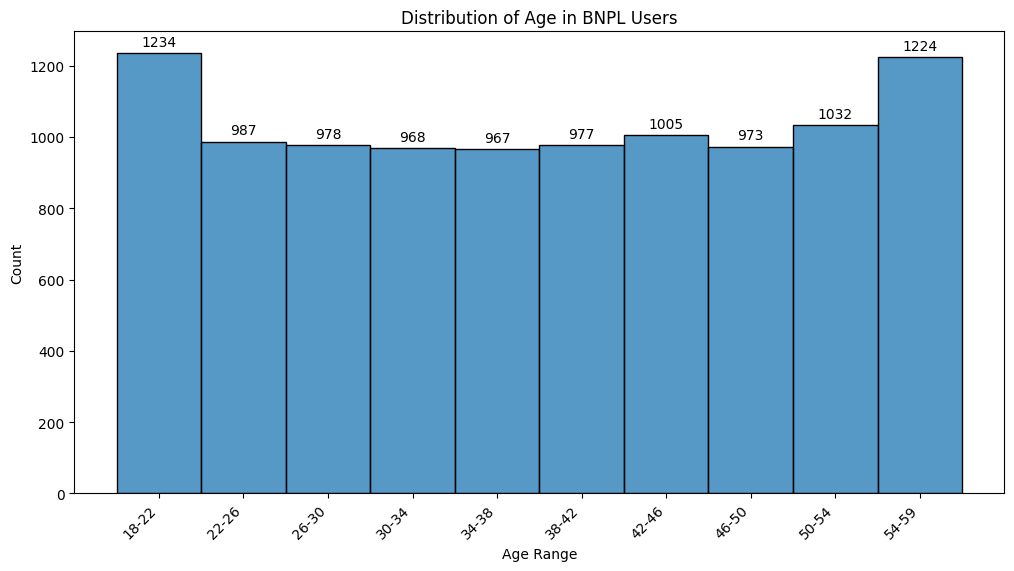

In [32]:
plt.figure(figsize=(12, 6))

ax = sns.histplot(df['age'], bins=10)

plt.title('Distribution of Age in BNPL Users')
plt.xlabel('Age Range')
plt.ylabel('Count')

# Bar labels and bin range labels
centers, labels = [], []

for p in ax.patches:
    h = p.get_height()
    left = p.get_x()
    right = left + p.get_width()

    if h > 0:
        ax.annotate(
            f'{int(h)}',
            (left + p.get_width() / 2, h),
            ha='center',
            xytext=(0, 5),
            textcoords='offset points'
        )

    centers.append(left + p.get_width() / 2)
    labels.append(f'{int(left)}-{int(right)}')

ax.set_xticks(centers)
ax.set_xticklabels(labels, rotation=45, ha='right')

plt.show()

Question: Which age groups use BNPL most frquently?

Top 5 Age Groups by Average App Usage Frequency:
age
40    5.818263
48    5.788577
46    5.769480
29    5.763820
41    5.708889
Name: app_usage_frequency, dtype: float64


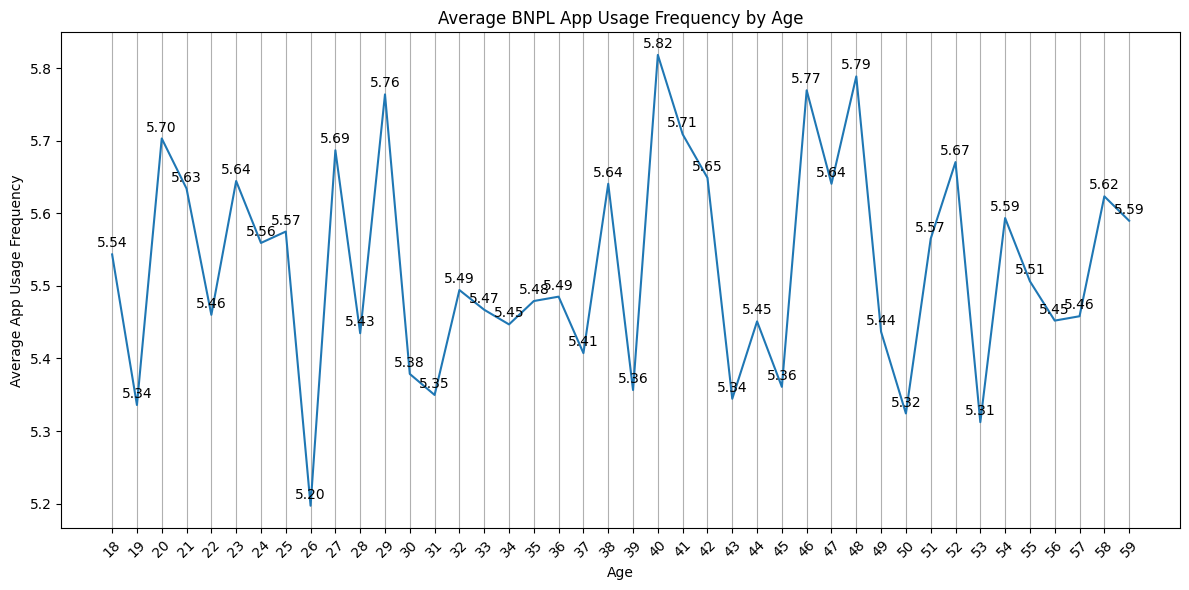

In [33]:
age_usage = df.groupby('age')['app_usage_frequency'].mean().sort_values(ascending=False)

print("Top 5 Age Groups by Average App Usage Frequency:")
print(age_usage.head())

plt.figure(figsize=(12, 6))

ax = sns.lineplot(x=age_usage.index, y=age_usage.values)

plt.title('Average BNPL App Usage Frequency by Age')
plt.xlabel('Age')
plt.ylabel('Average App Usage Frequency')

# Show all age labels
plt.xticks(age_usage.index, rotation=45)

ax.grid(True, axis='x')

for x, y in zip(age_usage.index, age_usage.values):
    ax.annotate(
        f'{y:.2f}',
        (x, y),
        ha='center',
        xytext=(0, 5),
        textcoords='offset points'
    )

plt.tight_layout()
plt.show()



---



> Insight: Most BNPL customers are young adults (18-22)


---




## 2: Income

Question: What is the income distribution?

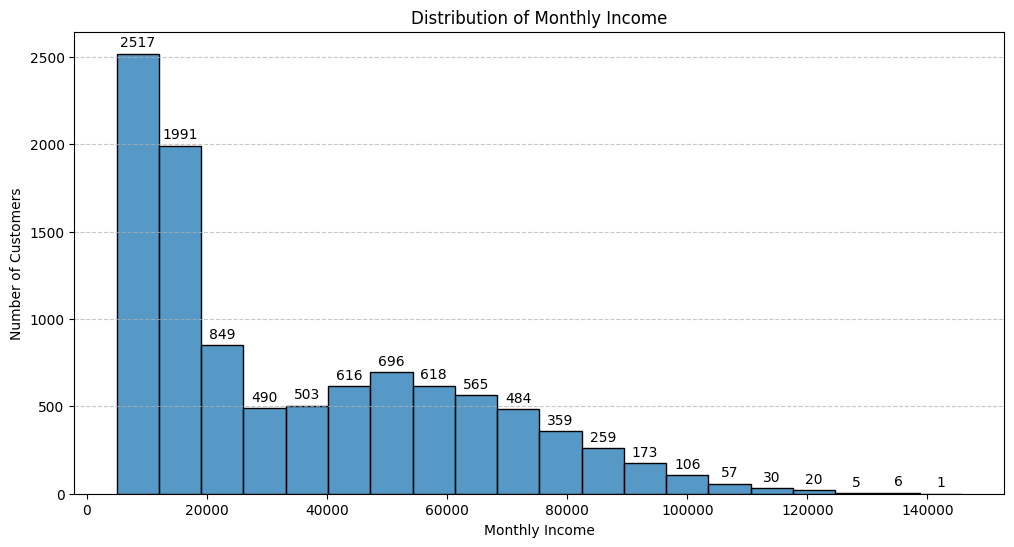

In [34]:
plt.figure(figsize=(12, 6))

ax = sns.histplot(df['monthly_income'], bins=20)

plt.title('Distribution of Monthly Income')
plt.xlabel('Monthly Income')
plt.ylabel('Number of Customers')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for p in ax.patches:
    if p.get_height():
        ax.annotate(
            f'{int(p.get_height())}',
            (p.get_x() + p.get_width()/2, p.get_height()),
            ha='center',
            xytext=(0, 5),
            textcoords='offset points'
        )

plt.show()

Question: Which income segments represent most customers?

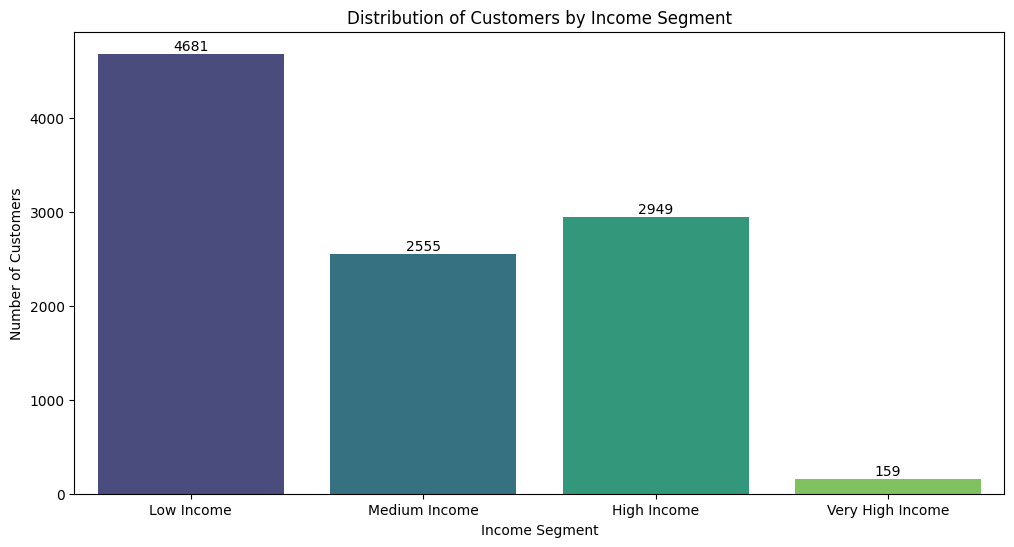

In [35]:
segments = pd.cut(
    df['monthly_income'],
    bins=[0, 20000, 50000, 100000, df['monthly_income'].max()],
    labels=['Low Income', 'Medium Income', 'High Income', 'Very High Income'],
    right=False
)

plt.figure(figsize=(12, 6))

ax = sns.countplot(x=segments, hue=segments, palette='viridis', legend=False)

plt.title('Distribution of Customers by Income Segment')
plt.xlabel('Income Segment')
plt.ylabel('Number of Customers')

for c in ax.containers:
    ax.bar_label(c)

plt.show()



---




> Insight: The low-income customers segment dominates BNPL usage




---



## 3: Credit Score

Qeustion: What is the distribution of credit score?

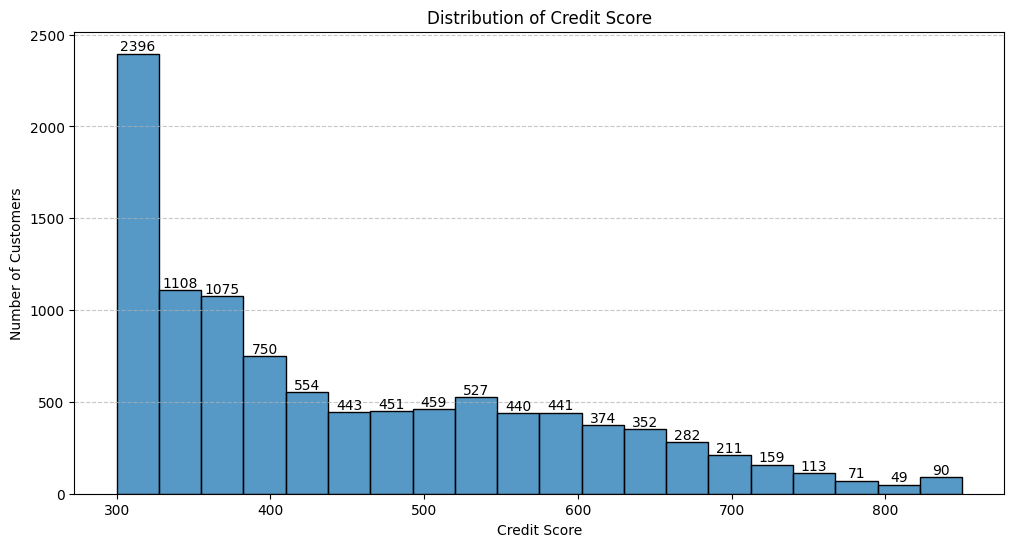

In [36]:
plt.figure(figsize=(12, 6))

ax = sns.histplot(df['credit_score'], bins=20)

plt.title('Distribution of Credit Score')
plt.xlabel('Credit Score')
plt.ylabel('Number of Customers')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for c in ax.containers:
    ax.bar_label(c)

plt.show()

Question: What percentage of customers have low, medium, high credit scores?

credit_score
Low Credit Score       80.49
Medium Credit Score    11.85
High Credit Score       7.66
Name: count, dtype: float64


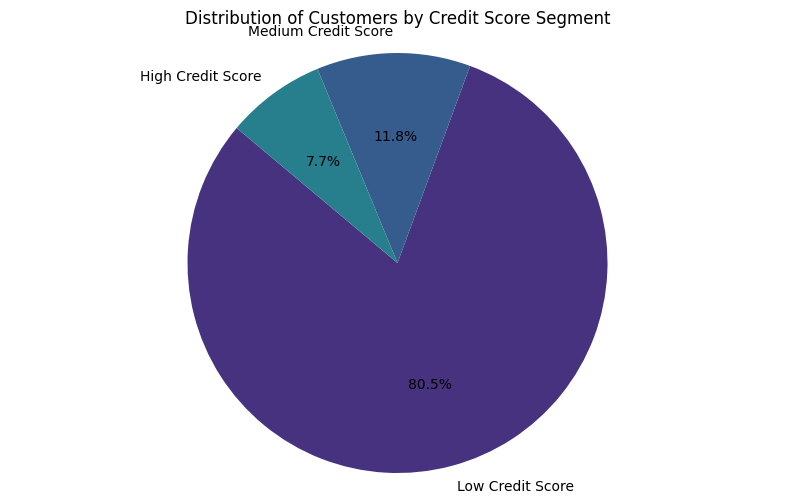

In [37]:
segments = pd.cut(
    df['credit_score'],
    bins=[300, 580, 670, 850],
    labels=['Low Credit Score', 'Medium Credit Score', 'High Credit Score'],
    right=False
)

counts = segments.value_counts()

print((counts / counts.sum() * 100).round(2))

plt.figure(figsize=(10, 6))

plt.pie(
    counts,
    labels=counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('viridis')
)

plt.title('Distribution of Customers by Credit Score Segment')
plt.axis('equal')
plt.show()

---






> Insight: Low-credit-score customers represent the bigger section in the customers-base which represent a significant portion of risk



---



## 4: Income & Credit Score

Question: Is there a relationship between income and credit score?

C:\Users\Omnia Hassan\AppData\Local\Temp\ipykernel_4092\2032205082.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_score = df.groupby(segments)['credit_score'].mean()


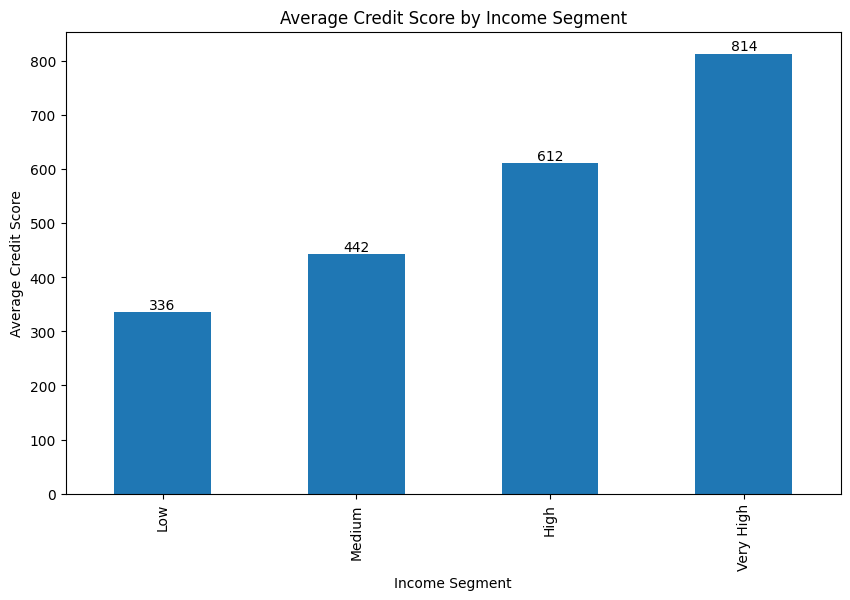

In [38]:
segments = pd.cut(
    df['monthly_income'],
    bins=[0, 20000, 50000, 100000, df['monthly_income'].max()],
    labels=['Low', 'Medium', 'High', 'Very High']
)

avg_score = df.groupby(segments)['credit_score'].mean()

plt.figure(figsize=(10,6))
ax = avg_score.plot(kind='bar')

plt.title('Average Credit Score by Income Segment')
plt.xlabel('Income Segment')
plt.ylabel('Average Credit Score')

for c in ax.containers:
    ax.bar_label(c, fmt='%.0f')

plt.show()



---




> Insight: Higher-income customers show stronger credit profiles




---



## 5: Product Categories

Question: Which categories are purchased most frequently?

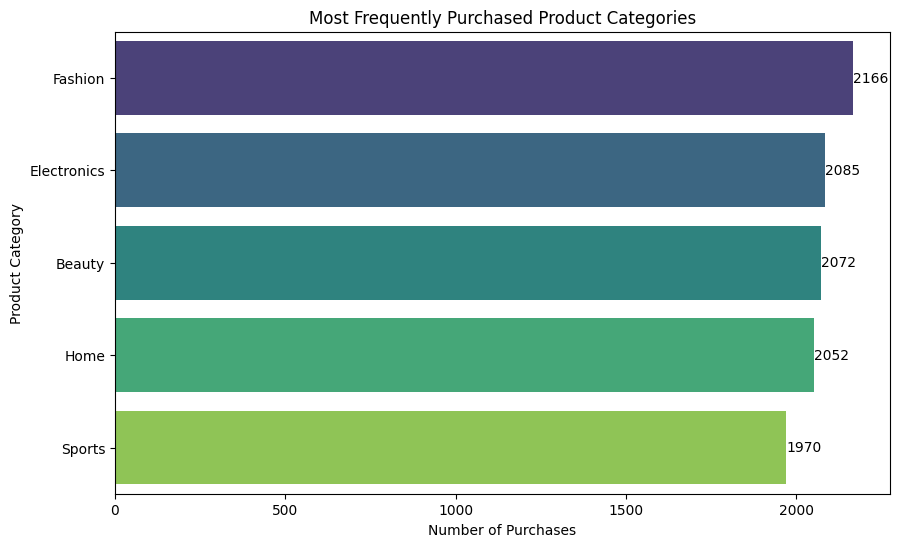

In [39]:
category_counts = df['product_category'].value_counts()

plt.figure(figsize=(10,6))
ax = sns.barplot(
    x=category_counts.values,
    y=category_counts.index,
    hue=category_counts.index,
    palette='viridis',
    legend=False
)

plt.title('Most Frequently Purchased Product Categories')
plt.xlabel('Number of Purchases')
plt.ylabel('Product Category')

for c in ax.containers:
    ax.bar_label(c)

plt.show()



---



> Insight: Fashion is the most frequently purchased category




---



Question: Which category generates the highest spending?

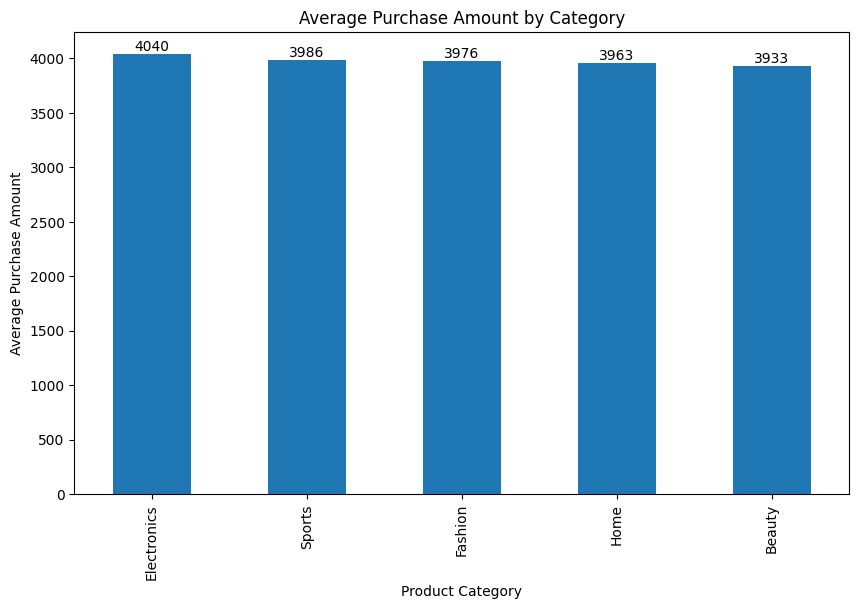

In [40]:
avg_purchase = (
    df.groupby('product_category')['purchase_amount']
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))
ax = avg_purchase.plot(kind='bar')

plt.title('Average Purchase Amount by Category')
plt.xlabel('Product Category')
plt.ylabel('Average Purchase Amount')

for c in ax.containers:
    ax.bar_label(c, fmt='%.0f')

plt.show()



---




> Insight: Electronics category drive most BNPL spendings




---



## 6: Repayment Behaviour

Question: How are repayment delays distributed?

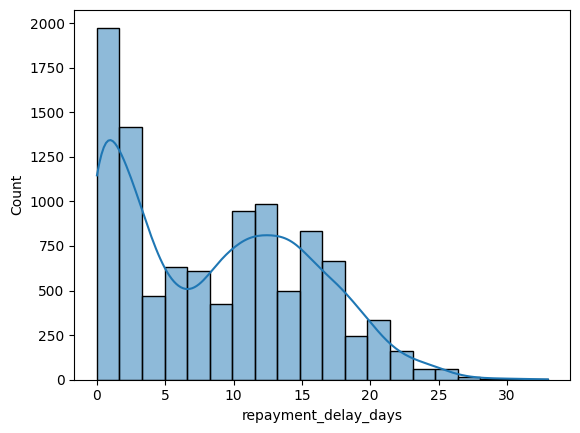

In [41]:
sns.histplot(df['repayment_delay_days'], bins=20, kde=True)
plt.show()



---



> Insight: Most Customers pay on time or with small delays



---



Question: What percentage of customers defaulted? (Default Rate)

In [42]:
df['default_flag'].value_counts()

default_flag
0    6305
1    4040
Name: count, dtype: int64

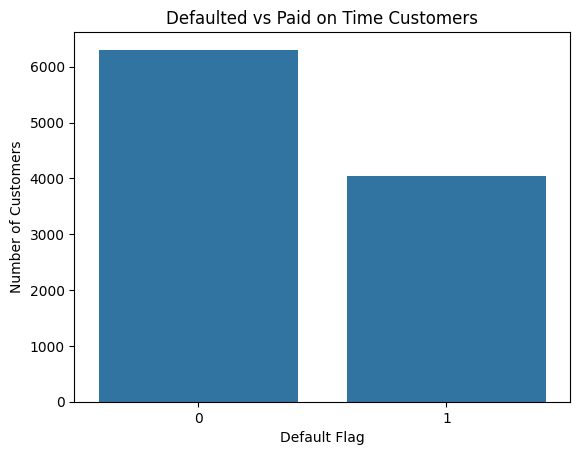

In [43]:
sns.countplot(data=df, x='default_flag')

plt.title('Defaulted vs Paid on Time Customers')
plt.xlabel('Default Flag')
plt.ylabel('Number of Customers')
plt.show()



---



> Insight: Most customers pay on time



---



Question: How many payments do customers typically miss?

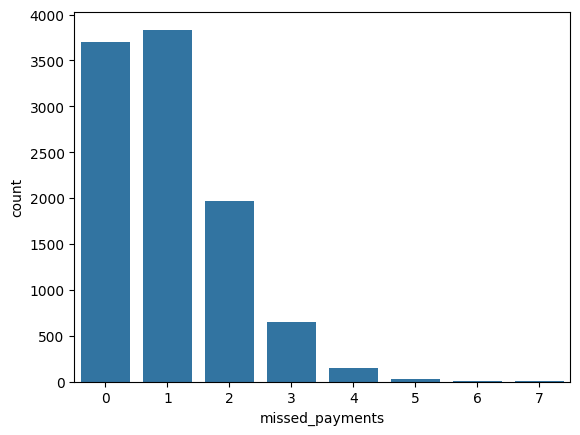

In [44]:
sns.countplot(x='missed_payments', data=df)
plt.show()



---



> Insight: Missed payments are not that common



---



## 7: Risk Analysis

Question: Does debt-to-income ratio affect repayment behavior?

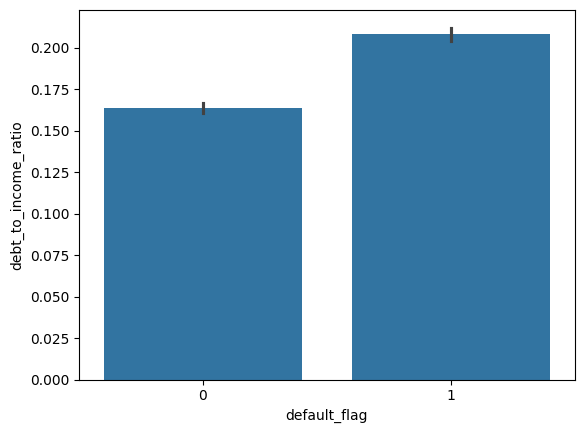

In [45]:
sns.barplot(
    x='default_flag',
    y='debt_to_income_ratio',
    data=df
)
plt.show()



> Insight: Higher DTI shows higher repayment risk



Risk & Repayment behavior factors

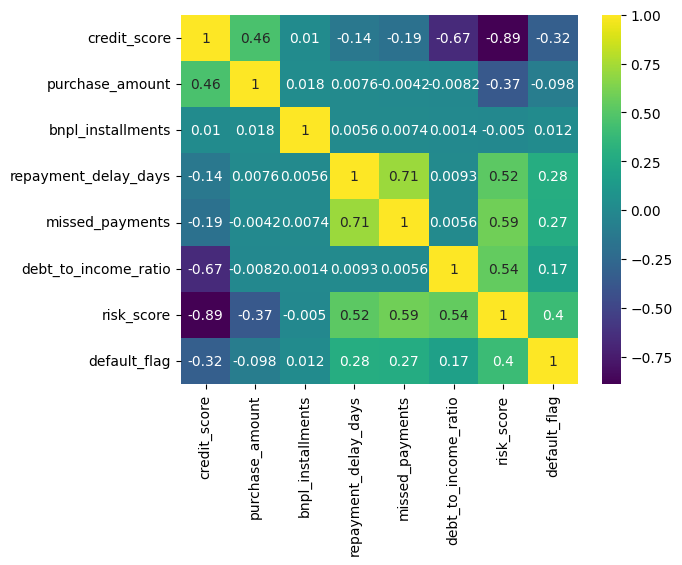

In [46]:
cols = [
    'credit_score',
    'purchase_amount',
    'bnpl_installments',
    'repayment_delay_days',
    'missed_payments',
    'debt_to_income_ratio',
    'risk_score',
    'default_flag'
]

sns.heatmap(
    df[cols].corr(),
    annot=True,
    cmap='viridis'
)
plt.show()

# Key Insights

Customer Profile

- The BNPL customer base is primarily composed of young adults, indicating that BNPL services are especially attractive to digitally engaged and convenience-oriented consumers.
- Low-income customers represent the largest segment of users, highlighting the importance of BNPL as a short-term financing solution for budget-conscious consumers.

Financial Behavior

- Customers with higher monthly incomes generally exhibit stronger credit profiles and better financial stability.
- Higher debt-to-income (DTI) ratios are associated with increased repayment risk, making DTI one of the most important indicators for credit assessment.
- Credit score remains a key factor in distinguishing low-risk and high-risk customers.

Purchasing Trends

- Fashion products are the most frequently purchased category through BNPL, indicating strong demand for installment-based payments in everyday consumer purchases.
- Electronics generate the highest average purchase amounts, exposing providers to higher financial risk per transaction despite lower purchase frequency.

Repayment Behavior

- Most customers repay their installments on time or with only minor delays, demonstrating generally healthy repayment behavior.
- The overall default rate remains relatively low, indicating that the majority of customers manage their BNPL obligations responsibly.
- Missed payments are not highly common but remain an early warning signal for potential future defaults.

Risk Analysis

- Customers with high DTI ratios, lower credit scores, and previous missed payments demonstrate a higher likelihood of repayment difficulties.
- Repayment delay patterns can be used as an early indicator of future default risk.
- Combining demographic, financial, and behavioral variables provides a stronger basis for risk assessment than relying on a single factor.

# Recommendations

Strengthen Credit Risk Assessment

- Incorporate credit score, debt-to-income ratio, repayment delays, and missed payment history into customer risk evaluation models.
- Develop automated risk segmentation to classify customers into Low, Medium, and High-Risk groups.

Improve Customer Monitoring

- Implement early-warning systems that detect increasing repayment delays before customers reach default status.
- Continuously monitor customers with high DTI ratios and repeated missed payments.

Optimize Product and Spending Limits

- Offer lower initial spending limits to new or high-risk customers.
- Gradually increase BNPL limits for customers who demonstrate consistent repayment behavior.
- Apply stricter approval rules for high-value categories such as Electronics due to their higher transaction amounts.

Enhance Customer Engagement

- Send automated payment reminders before due dates to reduce missed payments.
- Provide incentives and loyalty benefits for customers with strong repayment records.
- Offer financial education content to encourage responsible borrowing and repayment behavior.

Support Business Growth

- Focus marketing efforts on low-risk customer segments to maximize profitability while minimizing defaults.
- Use predictive analytics and machine learning models to improve approval decisions and portfolio performance.
- Regularly review risk policies to balance customer acquisition with sustainable growth.

# Machine Learning Modeling

In [47]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

In [48]:
df = df.drop(columns=['user_id', 'risk_score'])

In [49]:
X = df.drop(columns=['default_flag'])
y = df['default_flag']


In [50]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10345, 16)
y shape: (10345,)


In [51]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object', 'category']).columns

print("Numerical features:")
print(list(numeric_features))

print("\nCategorical features:")
print(list(categorical_features))

Numerical features:
['age', 'monthly_income', 'credit_score', 'purchase_amount', 'bnpl_installments', 'repayment_delay_days', 'missed_payments', 'app_usage_frequency', 'debt_to_income_ratio']

Categorical features:
['employment_type', 'product_category', 'location', 'customer_segment']


In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (8276, 16)
Testing set: (2069, 16)


In [53]:
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [54]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

## Model 1 - Logistic Regression

In [55]:
logistic_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [56]:
y_pred_lr = logistic_model.predict(X_test)
y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]

In [57]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.74      0.76      0.75      1261
           1       0.61      0.59      0.60       808

    accuracy                           0.69      2069
   macro avg       0.68      0.67      0.67      2069
weighted avg       0.69      0.69      0.69      2069



In [58]:
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)
lr_auc = roc_auc_score(y_test, y_prob_lr)

print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1 Score :", lr_f1)
print("ROC-AUC  :", lr_auc)

Accuracy : 0.6921217979700338
Precision: 0.6094750320102432
Recall   : 0.5891089108910891
F1 Score : 0.5991189427312775
ROC-AUC  : 0.75918157834816


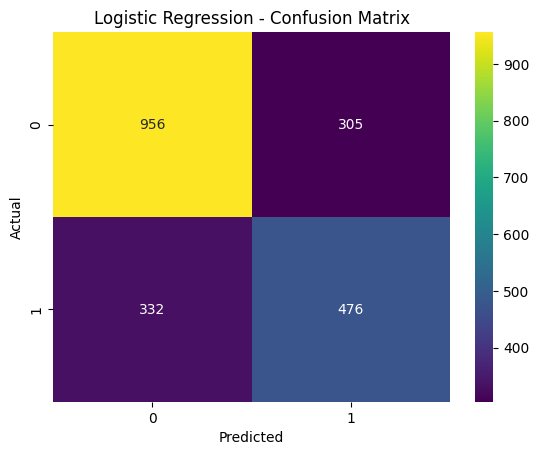

In [59]:
cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='viridis'
)

plt.title('Logistic Regression - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Model 2 - Decision Tree

In [60]:
decision_tree = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ))
])

decision_tree.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [61]:
y_pred_dt = decision_tree.predict(X_test)
y_prob_dt = decision_tree.predict_proba(X_test)[:, 1]

In [62]:
dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)
dt_auc = roc_auc_score(y_test, y_prob_dt)

print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", dt_recall)
print("F1 Score :", dt_f1)
print("ROC-AUC  :", dt_auc)

Accuracy : 0.7322377960367327
Precision: 0.7967289719626168
Recall   : 0.422029702970297
F1 Score : 0.551779935275081
ROC-AUC  : 0.7733676321636922


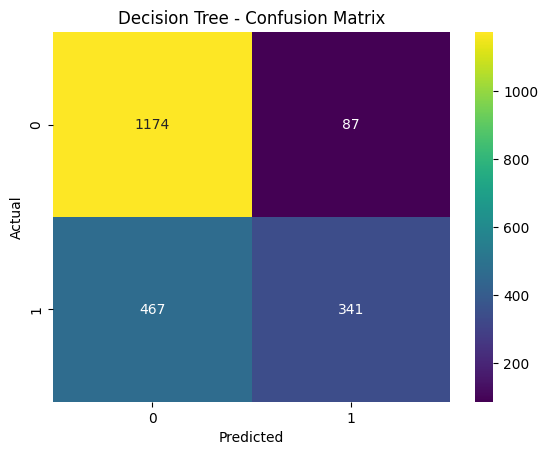

In [63]:
cm = confusion_matrix(y_test, y_pred_dt)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='viridis'
)

plt.title('Decision Tree - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Model 3 - Random Forest

In [64]:
random_forest = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight='balanced'
    ))
])

random_forest.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [65]:
y_pred_rf = random_forest.predict(X_test)
y_prob_rf = random_forest.predict_proba(X_test)[:, 1]

In [66]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, y_prob_rf)

print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)
print("ROC-AUC  :", rf_auc)

Accuracy : 0.7138714354760753
Precision: 0.7030075187969925
Recall   : 0.4628712871287129
F1 Score : 0.5582089552238806
ROC-AUC  : 0.7692778794136352


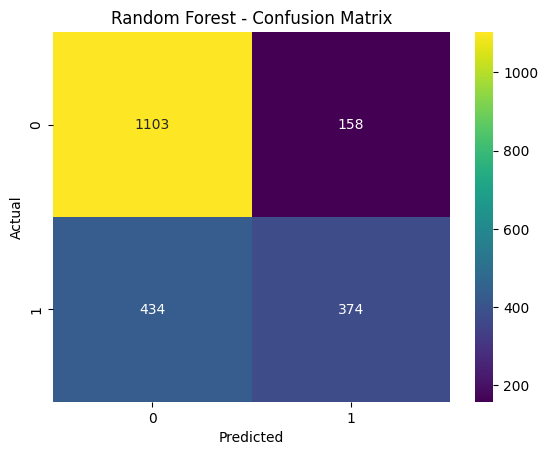

In [67]:
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='viridis'
)

plt.title('Random Forest - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Model 4 - Gradient Boosting

In [68]:
gradient_boosting = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ))
])

gradient_boosting.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [69]:
y_pred_gb = gradient_boosting.predict(X_test)
y_prob_gb = gradient_boosting.predict_proba(X_test)[:, 1]

In [70]:
gb_accuracy = accuracy_score(y_test, y_pred_gb)
gb_precision = precision_score(y_test, y_pred_gb)
gb_recall = recall_score(y_test, y_pred_gb)
gb_f1 = f1_score(y_test, y_pred_gb)
gb_auc = roc_auc_score(y_test, y_prob_gb)

print("Accuracy :", gb_accuracy)
print("Precision:", gb_precision)
print("Recall   :", gb_recall)
print("F1 Score :", gb_f1)
print("ROC-AUC  :", gb_auc)

Accuracy : 0.7351377477042049
Precision: 0.8170731707317073
Recall   : 0.4146039603960396
F1 Score : 0.5500821018062397
ROC-AUC  : 0.7758438611505876


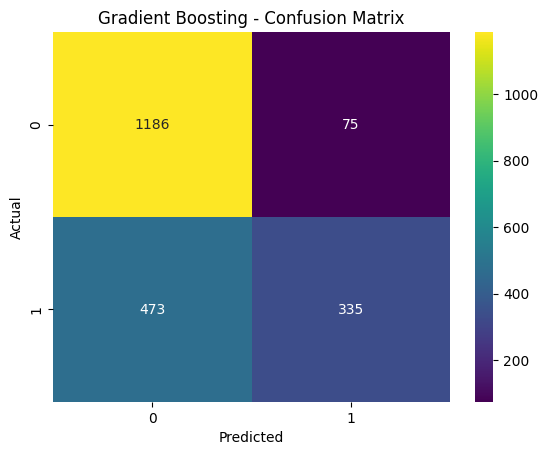

In [71]:
cm = confusion_matrix(y_test, y_pred_gb)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='viridis'
)

plt.title('Gradient Boosting - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Models Evaluation

In [72]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting'
    ],
    'Accuracy': [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy,
        gb_accuracy
    ],
    'Precision': [
        lr_precision,
        dt_precision,
        rf_precision,
        gb_precision
    ],
    'Recall': [
        lr_recall,
        dt_recall,
        rf_recall,
        gb_recall
    ],
    'F1 Score': [
        lr_f1,
        dt_f1,
        rf_f1,
        gb_f1
    ],
    'ROC-AUC': [
        lr_auc,
        dt_auc,
        rf_auc,
        gb_auc
    ]
})

results.sort_values('ROC-AUC', ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
3,Gradient Boosting,0.735138,0.817073,0.414604,0.550082,0.775844
1,Decision Tree,0.732238,0.796729,0.422030,0.551780,0.773368
2,Random Forest,0.713871,0.703008,0.462871,0.558209,0.769278
0,Logistic Regression,0.692122,0.609475,0.589109,0.599119,0.759182


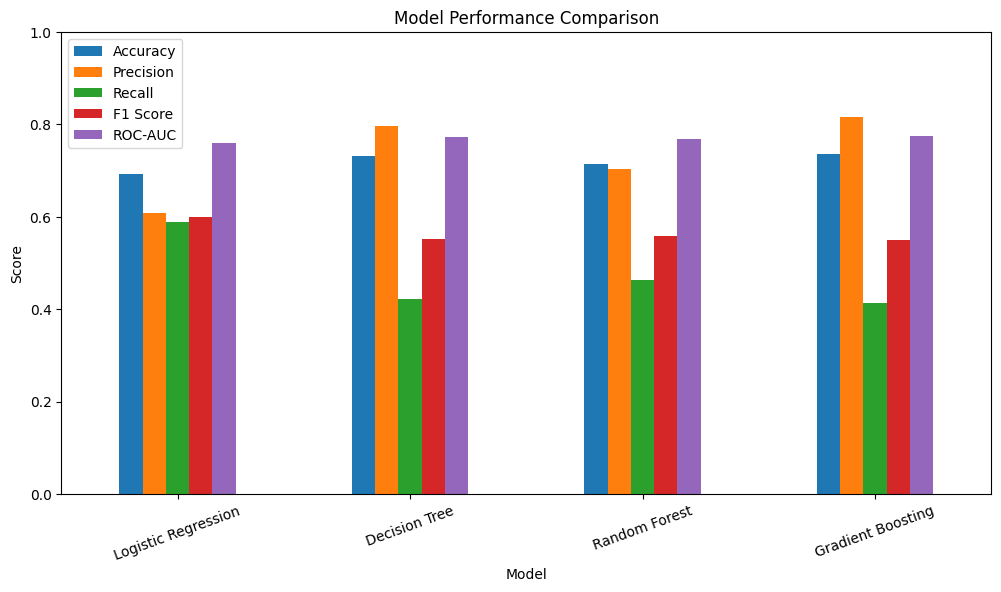

In [73]:
results.set_index('Model')[[
    'Accuracy',
    'Precision',
    'Recall',
    'F1 Score',
    'ROC-AUC'
]].plot(kind='bar', figsize=(12, 6))

plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.legend()
plt.show()

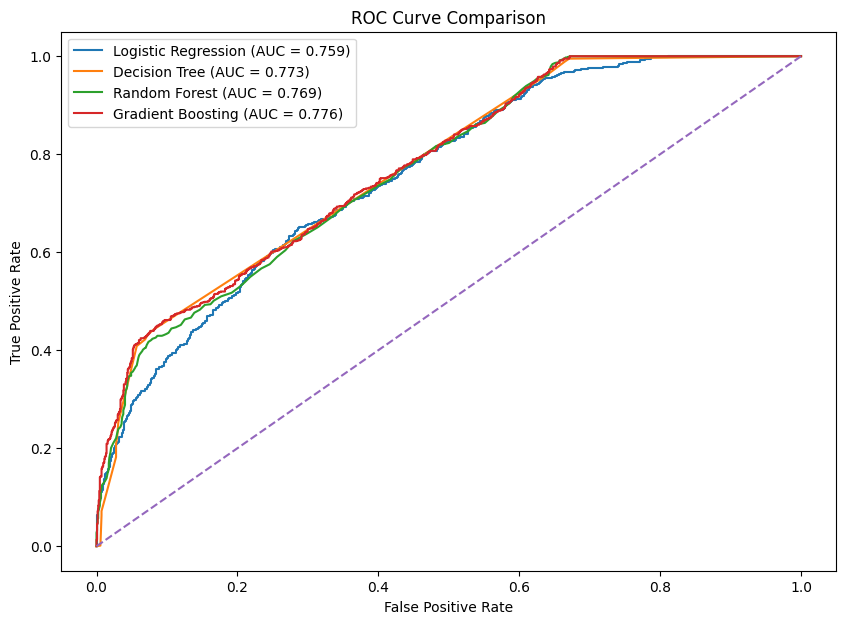

In [74]:
models_probabilities = {
    'Logistic Regression': y_prob_lr,
    'Decision Tree': y_prob_dt,
    'Random Forest': y_prob_rf,
    'Gradient Boosting': y_prob_gb
}

plt.figure(figsize=(10, 7))

for name, probabilities in models_probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, probabilities)
    auc = roc_auc_score(y_test, probabilities)

    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], '--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

In [75]:
results.sort_values(by=['Recall', 'ROC-AUC'], ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.692122,0.609475,0.589109,0.599119,0.759182
2,Random Forest,0.713871,0.703008,0.462871,0.558209,0.769278
1,Decision Tree,0.732238,0.796729,0.422030,0.551780,0.773368
3,Gradient Boosting,0.735138,0.817073,0.414604,0.550082,0.775844


In [76]:
best_model = gradient_boosting

# Risk Segment Test

In [77]:
def risk_segment(probability):

    if probability < 0.30:
        return "Low Risk"

    elif probability < 0.60:
        return "Medium Risk"

    else:
        return "High Risk"

In [78]:
test_results = X_test.copy()

test_results['Actual Default'] = y_test.values

test_results['Default Probability'] = (
    best_model.predict_proba(X_test)[:, 1]
)

test_results['Risk Segment'] = (
    test_results['Default Probability']
    .apply(risk_segment)
)

test_results.head(20)

,age,employment_type,monthly_income,credit_score,purchase_amount,product_category,bnpl_installments,repayment_delay_days,missed_payments,app_usage_frequency,location,transaction_date,debt_to_income_ratio,customer_segment,year,month,Actual Default,Default Probability,Risk Segment
4935,46,Student,20307.01,343,5000.00,Fashion,9,14,3,2.90,Australia,2023-03-15,0.246220,High Risk,2023,3,1,0.824046,High Risk
8720,23,Salaried,31899.13,447,5000.00,Electronics,3,2,0,1.05,USA,2024-08-16,0.156744,High Risk,2024,8,0,0.296380,Low Risk
9466,50,Salaried,96448.90,822,5000.00,Electronics,12,5,0,8.57,UK,2024-09-08,0.051841,Low Risk,2024,9,0,0.010992,Low Risk
1534,32,Unemployed,8160.67,304,564.24,Beauty,3,20,2,6.03,UK,2023-03-08,0.069141,High Risk,2023,3,1,0.694361,High Risk
613,22,Student,13239.44,310,5000.00,Fashion,6,11,1,4.40,India,2024-12-01,0.377659,High Risk,2024,12,1,0.378483,Medium Risk
1724,46,Unemployed,11880.93,300,2877.66,Electronics,9,12,1,3.48,India,2024-09-24,0.242208,High Risk,2024,9,1,0.411868,Medium Risk
533,36,Self-Employed,65824.06,588,5000.00,Fashion,3,16,1,7.12,USA,2023-02-10,0.075960,Medium Risk,2023,2,0,0.349976,Medium Risk
7472,26,Student,21213.66,385,5000.00,Electronics,3,0,0,1.39,Germany,2023-01-21,0.235697,High Risk,2023,1,0,0.433377,Medium Risk
7759,48,Student,16985.92,371,5000.00,Electronics,3,8,1,5.00,India,2023-06-30,0.294361,High Risk,2023,6,0,0.370020,Medium Risk
5333,28,Self-Employed,30243.87,428,5000.00,Beauty,6,1,0,7.39,India,2023-01-26,0.165323,High Risk,2023,1,1,0.383298,Medium Risk


In [79]:
risk_analysis = (
    test_results
    .groupby('Risk Segment')['Actual Default']
    .agg(['count', 'sum', 'mean'])
)

risk_analysis.columns = [
    'Customers',
    'Defaults',
    'Default Rate'
]

risk_analysis['Default Rate'] *= 100

risk_analysis

,Customers,Defaults,Default Rate
Risk Segment,,,
High Risk,398,330,82.914573
Low Risk,463,19,4.103672
Medium Risk,1208,459,37.996689


In [81]:
import joblib


joblib.dump(gradient_boosting, "bnpl_model.pkl")


['bnpl_model.pkl']

# Conclusion